# Customer Segmentation **Analysis**

### 📊 Overall Customer Segmentation Insights

- Customers were segmented into distinct groups using the K-Means clustering algorithm based on Annual Income and Spending Score.
- Each cluster represents a unique group of customers with similar purchasing behavior.
- The segmentation reveals clear differences in spending habits across income levels.

👉 This helps businesses understand customer diversity and design targeted strategies.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


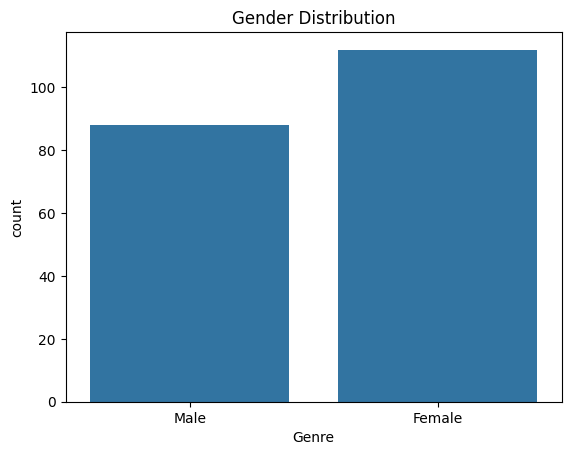

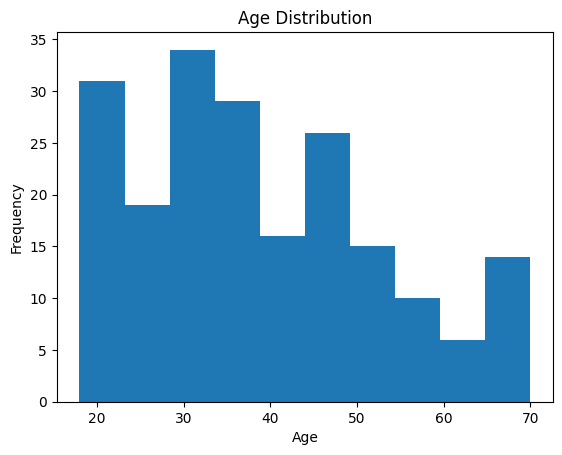

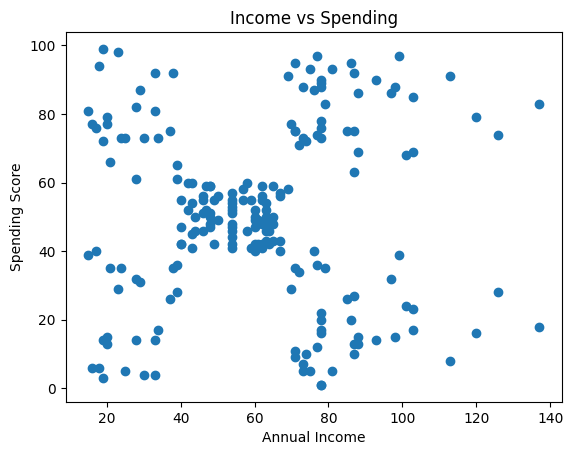

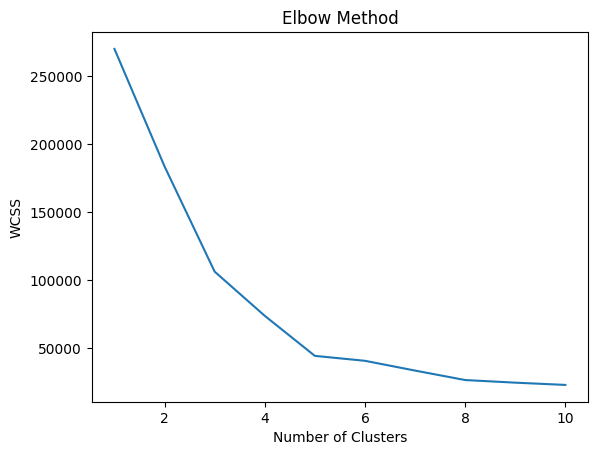

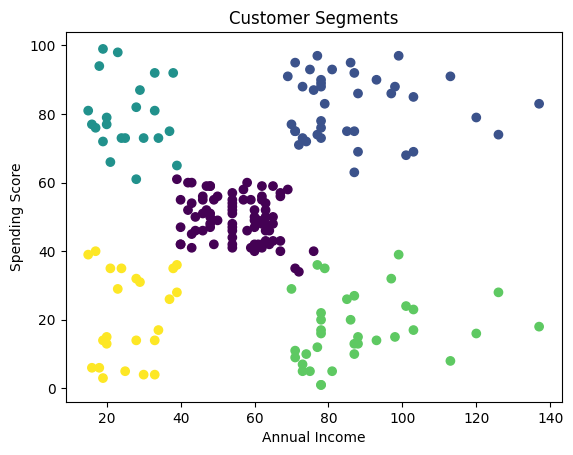

Cluster Centers:
 [[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


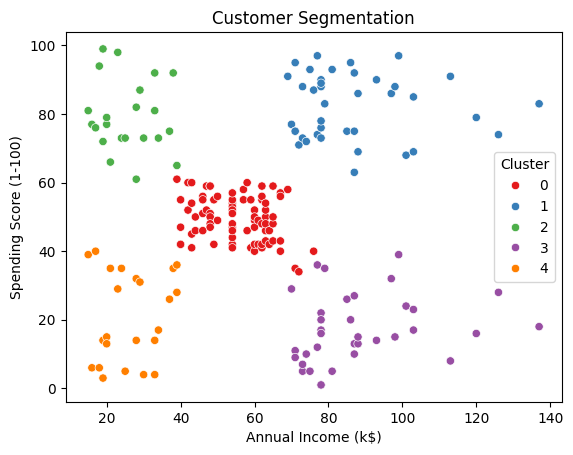

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
df = pd.read_csv("Mall_Customers.csv")
df.head()

df.info()
df.describe()
df.isnull().sum()
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

sns.countplot(x='Genre', data=df)
plt.title("Gender Distribution")
plt.show()

df['Age'].plot(kind='hist', bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending")
plt.show()

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

centers = kmeans.cluster_centers_
print("Cluster Centers:\n", centers)
df.groupby('Cluster').mean(numeric_only=True)

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df
)

plt.title("Customer Segmentation")
plt.show()
df.to_csv("customer_segmented_data.csv", index=False)

### 🎯 Final Business Recommendations

- Customer segmentation helps identify high-value and potential customers.
- Businesses should focus on retaining premium customers while converting moderate customers into high spenders.
- Personalized marketing strategies are more effective than general campaigns.

👉 Data-driven segmentation leads to better decision-making and increased profitability.